In [42]:
import pandas as pd
import numpy  as np
from tqdm import tqdm  #for showing progress bars
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from IPython.display import clear_output

In [43]:
import pandas as pd
import torch

x1 = pd.read_csv(r"C:\Users\Kashish Agrawal\Downloads\FODL_assignment\team19-20260226T071806Z-1-001\team19\task1\train_data.csv")

y1 = pd.read_csv(r"C:\Users\Kashish Agrawal\Downloads\FODL_assignment\team19-20260226T071806Z-1-001\team19\task1\train_label.csv")

inputs = torch.tensor(x1.values, dtype=torch.float32)
targets = torch.tensor(y1.values.flatten(), dtype=torch.long)
print(targets.shape)


torch.Size([1999])


In [44]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_1, hidden_2, output_size):
        super(NeuralNetwork, self).__init__()
        torch.manual_seed(42)
        self.fc1 = nn.Linear(input_size, hidden_1)  # First hidden layer
        self.fc2 = nn.Linear(hidden_1, hidden_2)  # Second hidden layer
        self.fc3 = nn.Linear(hidden_2, output_size)  # Output layer
        self.tanh = nn.Tanh()
        # tanh and softmax are activation fucntions

    def forward(self, x):
        x = self.tanh(self.fc1(x))# tanh after h1
        x = self.tanh(self.fc2(x)) #tanh after h2
        x = self.fc3(x)
        return x # x is the output feature vector given by the model

In [45]:
def plot(loss_array, title_):
  plt.clf()
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(f"Loss Curve During Training - {title_}")
  plt.plot(list(range(len(loss_array))), loss_array, label="Training Loss", color ="blue")
  plt.legend()
  plt.show()
  print(loss_array)

In [46]:
#Hyper parameters
criterion = nn.CrossEntropyLoss() #loss function
learning_rate = 0.001
max_epochs = 1000
thershold_error = 0.00005


In [47]:
#ADAM

In [48]:
model_adam = NeuralNetwork(input_size=36, hidden_1=20, hidden_2=10, output_size=5)
optimiser_adam = optim.Adam(model_adam.parameters(), lr=learning_rate)
loss_adam=[]

In [55]:
#Training :
error = 0
no_epoch =0
past_error = 1000.0000000000


for epoch in tqdm(range(max_epochs), desc="Training Progress", unit="epoch"):
    error = 0
    indices = list(range(len(inputs)))  # Create a list of indices
    random.shuffle(indices)
    for i in indices:
        x = inputs[i].unsqueeze(0)  # Get input sample (reshape to batch)
        y = targets[i].unsqueeze(0)  # Get target value

        # Forward pass
        optimiser_adam.zero_grad()
        output = model_adam(x)
        loss = criterion(output, y)

        # Compute weight updates manually using Delta Rule
        loss.backward()  # Compute gradients
        optimiser_adam.step()

        error += loss.item()

    avg_loss = error / len(inputs)  # Compute average loss per epoch
    loss_adam.append(avg_loss)
    no_epoch += 1

    if abs(past_error-avg_loss) < thershold_error :
        break
    past_error = avg_loss

Training Progress:   7%|▋         | 68/1000 [01:21<18:37,  1.20s/epoch]


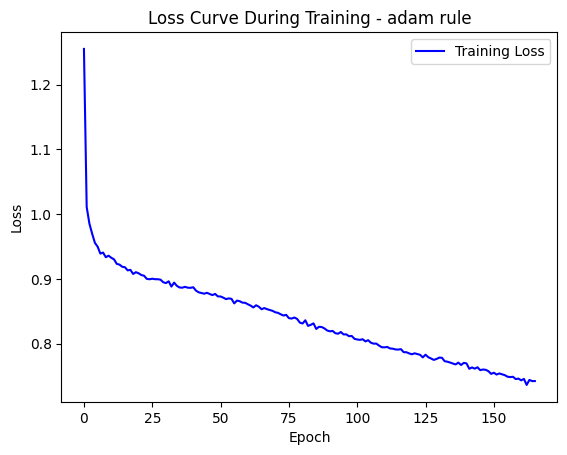

[1.2551718112230374, 1.0110071345231029, 0.9852540905446675, 0.9698262411404286, 0.9557623839862608, 0.9497622655090336, 0.9390523692763263, 0.9406339234814352, 0.9334903999098743, 0.935832369710021, 0.9326053794929753, 0.930199454554714, 0.9232154824673615, 0.9220288668446086, 0.918749742927272, 0.9179281938937318, 0.9131124651518647, 0.9139294329085613, 0.9075858691911548, 0.9103571099100803, 0.9086848074075752, 0.9059602420429059, 0.9048404444909174, 0.9000044247003206, 0.8994256416805091, 0.9002394776935995, 0.8995190508736567, 0.8994518043012127, 0.8988556520176633, 0.8948596074686606, 0.8934632384215014, 0.8962557843396894, 0.8881228364029877, 0.8942568583652496, 0.8892193960528839, 0.8866847037291596, 0.8864196583045355, 0.8876938995387612, 0.886374470791437, 0.8861926603919522, 0.8870511791436351, 0.8818568993914684, 0.8792374512620257, 0.8781338703968637, 0.8771070505548529, 0.8784476423636312, 0.8766795460051117, 0.8749490412619065, 0.87679159489594, 0.8729327172009491, 0.872

In [56]:

plot(loss_adam, "adam rule")
print(past_error)
print("No.of epoch")
print(no_epoch)

In [51]:
#ADAGRAD

In [52]:
model_adagrad = NeuralNetwork(input_size=36, hidden_1=20, hidden_2=10, output_size=5)
optimiser_adagrad = optim.Adagrad(model_adagrad.parameters(), lr=learning_rate)
loss_adagrad=[]

In [53]:
#Training :
error = 0
no_epoch =0
past_error = 1000.00000000


for epoch in tqdm(range(max_epochs), desc="Training Progress", unit="epoch"):
    error = 0
    indices = list(range(len(inputs)))  # Create a list of indices
    random.shuffle(indices)
    for i in indices:
        x = inputs[i].unsqueeze(0)  # Get input sample (reshape to batch)      
        y = targets[i].unsqueeze(0)  # Get target value


        # Forward pass
        optimiser_adagrad.zero_grad()
        output = model_adagrad(x)
        loss = criterion(output, y)

        # Compute weight updates manually using Delta Rule
        loss.backward()  # Compute gradients
        optimiser_adagrad.step()

        error += loss.item()

    avg_loss = error / len(inputs)  # Compute average loss per epoch
    loss_adagrad.append(avg_loss)
    no_epoch += 1

    if abs(past_error-avg_loss) < thershold_error :
        break
    past_error = avg_loss

Training Progress:  13%|█▎        | 131/1000 [02:05<13:49,  1.05epoch/s]


KeyboardInterrupt: 

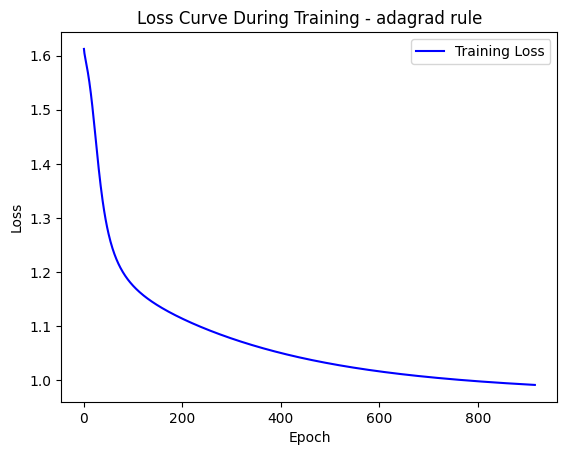

[1.612287766519578, 1.6040967787546536, 1.598617687232498, 1.5936938622046735, 1.5889141923967394, 1.5841097800716153, 1.5791854999732113, 1.574075911687934, 1.5687324306617803, 1.5631206469156553, 1.5572153509348974, 1.5509912923552382, 1.5444400995716325, 1.5375516551205253, 1.5303265536767712, 1.5227742461099094, 1.5149098143928226, 1.506754733133817, 1.4983337142576034, 1.489687664917912, 1.4808544985588459, 1.4718694354725694, 1.4627767990027862, 1.453616432782231, 1.4444355370105058, 1.4352762537219632, 1.4261772757234903, 1.4171780513309729, 1.4083111532155486, 1.3996044734288837, 1.3910875572688344, 1.3827833970407655, 1.3747051858556099, 1.3668701597575608, 1.3592845874318127, 1.3519538608326085, 1.3448864493356936, 1.3380769160075328, 1.331524949526417, 1.3252270200838143, 1.3191800141048289, 1.3133751263673332, 1.3078056340846138, 1.302463480104143, 1.2973421940718848, 1.292431022194757, 1.2877211536375388, 1.2832029094288742, 1.278868397171346, 1.2747091923343234, 1.2707162

In [ ]:
plot(loss_adagrad, "adagrad rule")
print(past_error)
print("No.of epoch")
print(no_epoch)

In [ ]:
#RMS PROP

In [ ]:
model_rms = NeuralNetwork(input_size=36, hidden_1=20, hidden_2=10, output_size=5)
optimiser_rms = optim.RMSprop(model_rms.parameters(), lr=learning_rate)
loss_rms=[]

In [ ]:
#Training :
error = 0
no_epoch =0
past_error = 1000.000000


for epoch in tqdm(range(max_epochs), desc="Training Progress", unit="epoch"):
    error = 0
    indices = list(range(len(inputs)))  # Create a list of indices
    random.shuffle(indices)
    for i in indices:
        x = inputs[i].unsqueeze(0)  # Get input sample (reshape to batch)
        y = targets[i].unsqueeze(0)  # Get target value

        # Forward pass
        optimiser_rms.zero_grad()
        output = model_rms(x)
        loss = criterion(output, y)

        # Compute weight updates manually using Delta Rule
        loss.backward()  # Compute gradients
        optimiser_rms.step()

        error += loss.item()

    avg_loss = error / len(inputs)  # Compute average loss per epoch
    loss_rms.append(avg_loss)
    no_epoch += 1

    if abs(past_error-avg_loss) < thershold_error  :
        break
    past_error = avg_loss

Training Progress:   4%|▍         | 42/1000 [00:43<16:27,  1.03s/epoch]


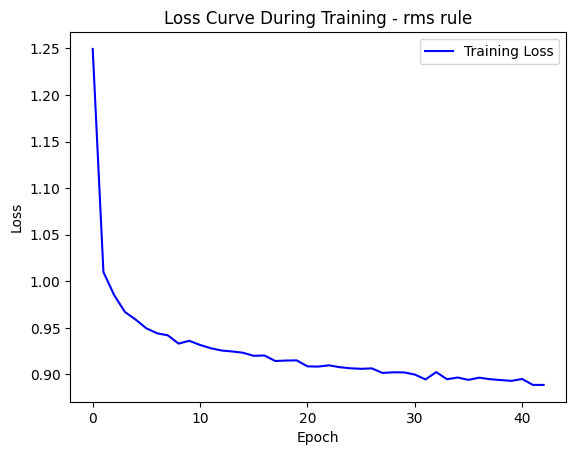

[1.2495426491318478, 1.0099369224450696, 0.9851696876691479, 0.967127042860219, 0.9589056940363178, 0.9494873805087117, 0.9441897700609557, 0.9419912611709846, 0.9330943893658006, 0.9361473178927073, 0.9316498989580836, 0.9281532482281696, 0.925712686213872, 0.9246632530951007, 0.9232920468597928, 0.9199829591827079, 0.9203381076265963, 0.9144518060882013, 0.9149077843826123, 0.9151169457558469, 0.9086863793588904, 0.9084378733495814, 0.9097716617563356, 0.9078100604965949, 0.9066115003305135, 0.906044175686583, 0.9065155632664151, 0.9015906483423325, 0.9023155940819709, 0.9021814547956345, 0.8998916273014275, 0.8946661164492239, 0.9025310628797967, 0.8948467248892216, 0.8967201678136973, 0.8941758972281784, 0.8965364229921745, 0.8949008132657782, 0.8939916596020208, 0.8930936189613078, 0.8951194590716886, 0.8887639858853351, 0.8887465426671771]
0.8887639858853351
No.of epoch
43


In [ ]:
plot(loss_rms, "rms rule")
print(past_error)
print("No.of epoch")
print(no_epoch)

In [ ]:
#DELTA RULES

In [ ]:
model_grad = NeuralNetwork(input_size=36, hidden_1=20, hidden_2=10, output_size=5)
optimiser_grad = optim.SGD(model_grad.parameters(), lr=learning_rate)
loss_grad=[]

In [ ]:
#Training :
error = 0
no_epoch =0
past_error = 1000.000000


for epoch in tqdm(range(max_epochs), desc="Training Progress", unit="epoch"):
    error = 0
    indices = list(range(len(inputs)))  # Create a list of indices
    random.shuffle(indices)
    for i in indices:
        x = inputs[i].unsqueeze(0)  # Get input sample (reshape to batch)
        y = targets[i].unsqueeze(0) # Get target value

        # Forward pass
        optimiser_grad.zero_grad()
        output = model_grad(x)
        loss = criterion(output, y)

        # Compute weight updates manually using Delta Rule
        loss.backward()  # Compute gradients
        optimiser_grad.step()

        error += loss.item()

    avg_loss = error / len(inputs)  # Compute average loss per epoch
    loss_grad.append(avg_loss)
    no_epoch += 1

    if abs(past_error-avg_loss) < thershold_error  :
        break
    past_error = avg_loss

Training Progress:  19%|█▉        | 194/1000 [02:13<09:14,  1.45epoch/s]


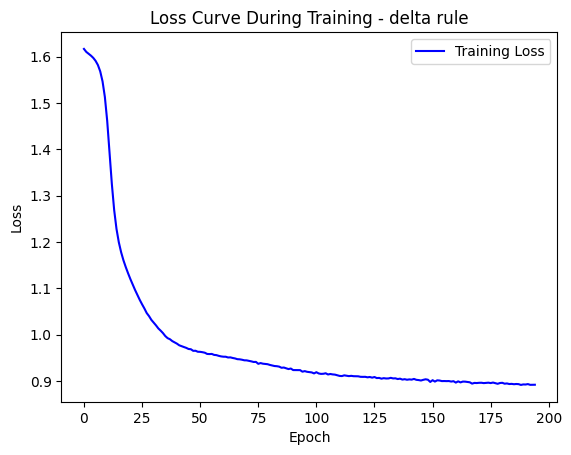

[1.6164406505807034, 1.6100383425665354, 1.6060877733077927, 1.6019958853423446, 1.5971781221135013, 1.590722624452905, 1.5817462702045564, 1.5680150991084876, 1.5463979049227488, 1.5127366920183039, 1.4613257656102183, 1.3945597180311176, 1.3252399169680118, 1.268840463818044, 1.2281084238267828, 1.199229666106906, 1.1775897281573318, 1.1601542640037614, 1.145479230016373, 1.1320891806985316, 1.1194560388014607, 1.1076291528166555, 1.0961358329717288, 1.0854648907704763, 1.0749361267422382, 1.065367561312166, 1.0563775423071857, 1.046446121508361, 1.0398256727072666, 1.0317220338082138, 1.0257173378412807, 1.0198495501331826, 1.0132577089767991, 1.0084406347426327, 1.0031403391107194, 0.9967386932536241, 0.9922416423996719, 0.989924631709314, 0.9859034449086637, 0.9831599747552897, 0.9804070146312717, 0.9768374468353188, 0.9750918208413187, 0.9730984734260888, 0.9713245013415657, 0.9688622557623111, 0.9683326365944024, 0.964888586357782, 0.9650633494832551, 0.9628846969215779, 0.96272

In [ ]:
plot(loss_grad, "delta rule")
print(past_error)
print("No.of epoch")
print(no_epoch)

In [ ]:
#Generalised delta rules

In [ ]:
model_gen_grad = NeuralNetwork(input_size=36, hidden_1=20, hidden_2=10, output_size=5)
optimiser_gen_grad = optim.SGD(model_gen_grad.parameters(), lr=learning_rate, momentum = 0.1)
loss_gen_grad=[]

In [ ]:
#Training :
error = 0
no_epoch =0
past_error = 1000.00000


for epoch in tqdm(range(max_epochs), desc="Training Progress", unit="epoch"):
    error = 0
    indices = list(range(len(inputs)))  # Create a list of indices
    random.shuffle(indices)
    for i in indices:
        x = inputs[i].unsqueeze(0)  # Get input sample (reshape to batch)
        y = targets[i].unsqueeze(0)  # Get target value

        # Forward pass
        optimiser_gen_grad.zero_grad()
        output = model_gen_grad(x)
        loss = criterion(output, y)

        # Compute weight updates manually using Delta Rule
        loss.backward()  # Compute gradients
        optimiser_gen_grad.step()

        error += loss.item()

    avg_loss = error / len(inputs)  # Compute average loss per epoch
    loss_gen_grad.append(avg_loss)
    no_epoch += 1

    if abs(past_error-avg_loss) < thershold_error :
        break
    past_error = avg_loss

Training Progress:  18%|█▊        | 177/1000 [02:21<10:55,  1.26epoch/s]


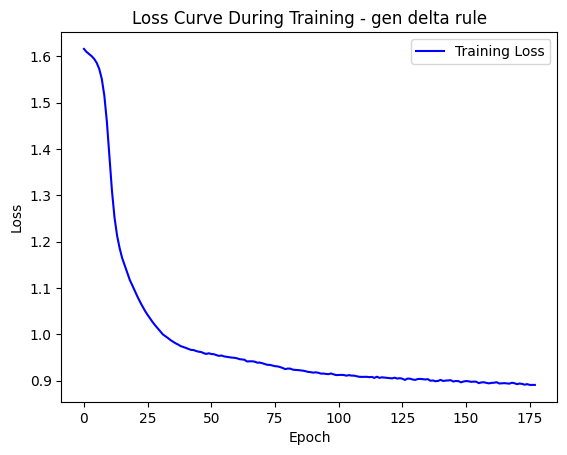

[1.6157262384921327, 1.609331593804505, 1.6049176855287652, 1.6001976742155257, 1.5942826096328155, 1.5857193230270683, 1.572570347082263, 1.5510790662922938, 1.5150536625846855, 1.4584545937402658, 1.3835345008571247, 1.3092355199788082, 1.2517528604676929, 1.213049929572261, 1.185905804873452, 1.1643151390632283, 1.1485085779742308, 1.1328589908858802, 1.1171346508654179, 1.1053477034057533, 1.0932820493377757, 1.0811317697253122, 1.0701619260550745, 1.0598490749872016, 1.0501763902743417, 1.041653762706157, 1.0336352386952132, 1.0258832188801148, 1.0188464697323676, 1.0122850688622558, 1.0056834100741425, 0.999488774421725, 0.9956448441837216, 0.9916347828453752, 0.9872835828629641, 0.9837733677044704, 0.9803024907540502, 0.9775985286516575, 0.974251972986157, 0.9725239665668901, 0.9704540768296287, 0.968300480807639, 0.9662180475845444, 0.9658256458060787, 0.9638697326904523, 0.9622648655721827, 0.9616544301206504, 0.9591381431317536, 0.9574471440202574, 0.9589048224738219, 0.95729

In [ ]:
plot(loss_gen_grad, "gen delta rule")
print(past_error)
print("No.of epoch")
print(no_epoch)

In [ ]:
#Confusion matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
import pandas as pd
import torch

base_path = r"C:\Users\Kashish Agrawal\Downloads\FODL_assignment\team19-20260226T071806Z-1-001\team19\task1\\"

test_i = torch.tensor(
    pd.read_csv(base_path + "test_data.csv").values,
    dtype=torch.float32
)

test_o = torch.tensor(
    pd.read_csv(base_path + "test_label.csv").values.flatten(),
    dtype=torch.long
)

print(test_i.shape)
print(test_o.shape)

torch.Size([499, 36])
torch.Size([499])


In [ ]:
desired = targets.numpy()
test_o = test_o.numpy()

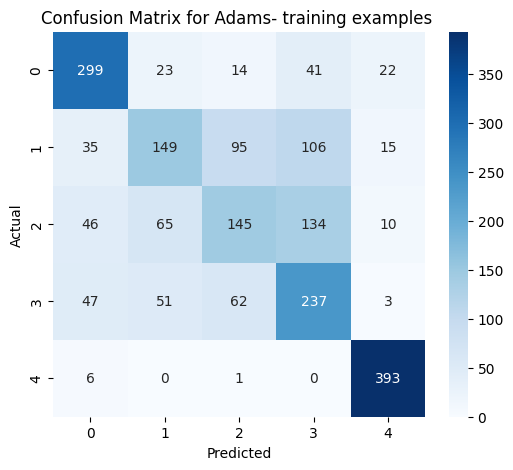

In [ ]:
#adams
adam_op = model_adam(inputs)
predictions_adam = torch.argmax(adam_op, dim=1)
pred_adam = predictions_adam.numpy()
cm_adam = confusion_matrix(desired, pred_adam)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adam, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Adams- training examples ")
plt.show()

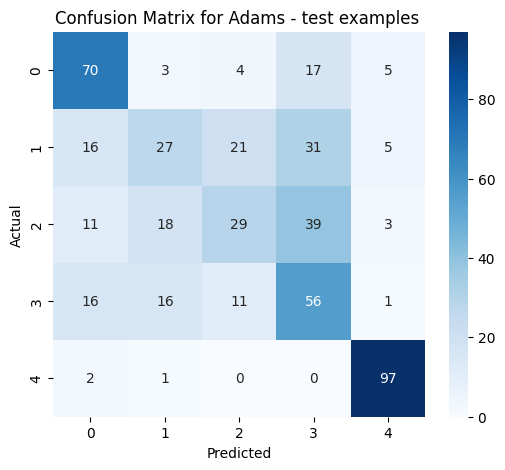

In [ ]:
adam_op_t = model_adam(test_i)
predictions_adam_t = torch.argmax(adam_op_t, dim=1)
pred_adam_t = predictions_adam_t.numpy()
cm_adam_t = confusion_matrix(test_o, pred_adam_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adam_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Adams - test examples ")
plt.show()

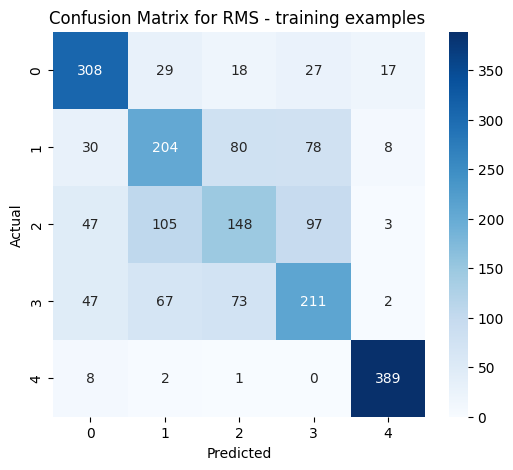

In [ ]:
#rms
rms_op = model_rms(inputs)
predictions_rms = torch.argmax(rms_op, dim=1)
pred_rms = predictions_rms.numpy()
cm_rms = confusion_matrix(desired, pred_rms)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rms, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for RMS - training examples ")
plt.show()

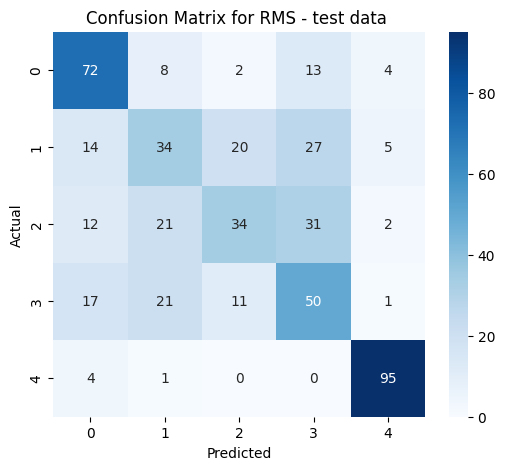

In [ ]:
rms_op_t = model_rms(test_i)
predictions_rms_t = torch.argmax(rms_op_t, dim=1)
pred_rms_t = predictions_rms_t.numpy()
cm_rms_t = confusion_matrix(test_o, pred_rms_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rms_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for RMS - test data ")
plt.show()

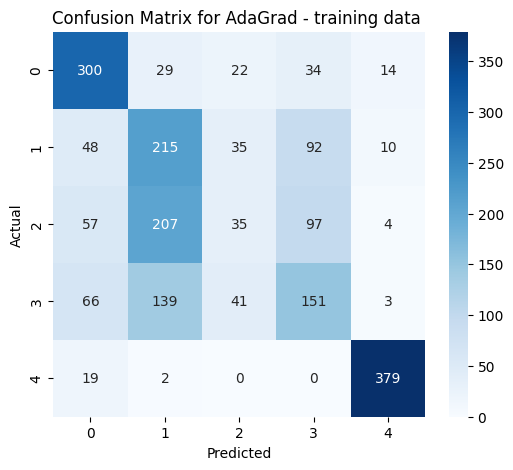

In [ ]:
#adagrad
adagrad_op = model_adagrad(inputs)
predictions_adagrad = torch.argmax(adagrad_op, dim=1)
pred_adagrad = predictions_adagrad.numpy()
cm_adagrad = confusion_matrix(desired, pred_adagrad)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adagrad, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for AdaGrad - training data ")
plt.show()

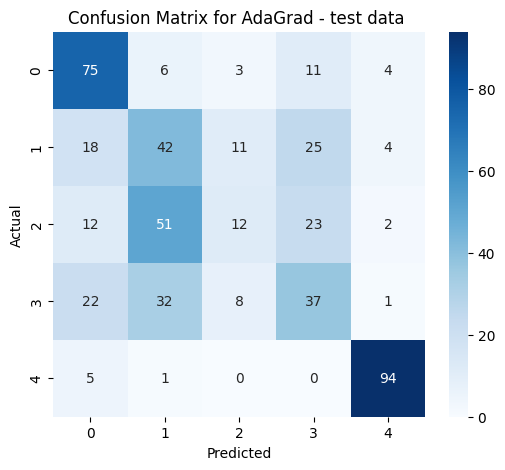

In [ ]:
adagrad_op_t = model_adagrad(test_i)
predictions_adagrad_t = torch.argmax(adagrad_op_t, dim=1)
pred_adagrad_t = predictions_adagrad_t.numpy()
cm_adagrad_t = confusion_matrix(test_o, pred_adagrad_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adagrad_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for AdaGrad - test data ")
plt.show()

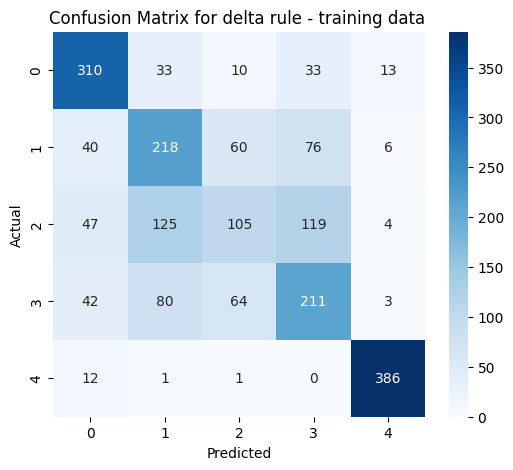

In [ ]:
#delta
delta_op = model_grad(inputs)
predictions_delta = torch.argmax(delta_op, dim=1)
pred_delta = predictions_delta.numpy()
cm_delta = confusion_matrix(desired, pred_delta)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_delta, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for delta rule - training data ")
plt.show()

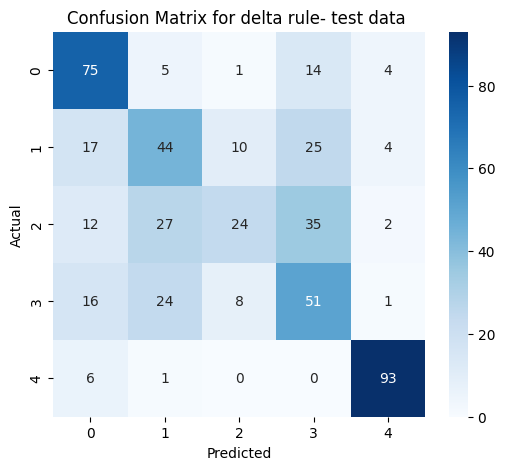

In [ ]:
delta_op_t = model_grad(test_i)
predictions_delta_t = torch.argmax(delta_op_t, dim=1)
pred_delta_t = predictions_delta_t.numpy()
cm_delta_t = confusion_matrix(test_o, pred_delta_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_delta_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for delta rule- test data ")
plt.show()

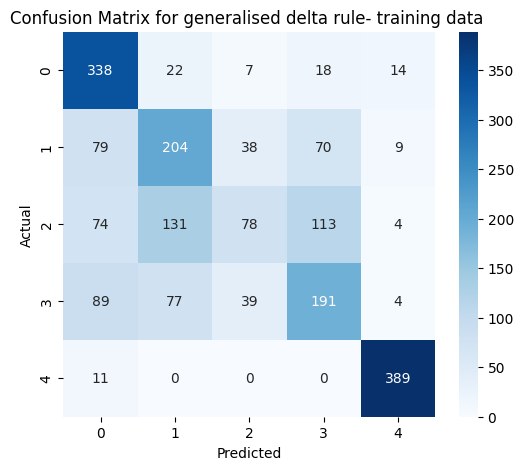

In [ ]:
#generlaised delta rule
gen_delta_op = model_gen_grad(inputs)
predictions_gen_delta = torch.argmax(gen_delta_op, dim=1)
pred_gen_delta = predictions_gen_delta.numpy()
cm_gen_delta = confusion_matrix(desired, pred_gen_delta)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gen_delta, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for generalised delta rule- training data ")
plt.show()

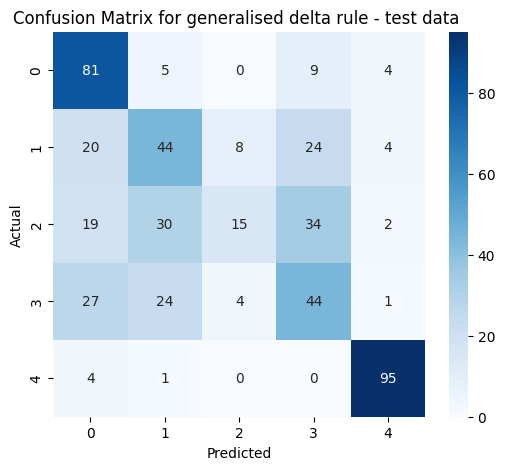

In [ ]:
gen_delta_op_t = model_gen_grad(test_i)
predictions_gen_delta_t = torch.argmax(gen_delta_op_t, dim=1)
pred_gen_delta_t = predictions_gen_delta_t.numpy()
cm_gen_delta_t = confusion_matrix(test_o, pred_gen_delta_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gen_delta_t, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for generalised delta rule - test data ")
plt.show()